In [38]:
# ===============================
# import packages
# ===============================
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from datetime import datetime as dt, timezone, timedelta
from pathlib import Path
import squarify

In [39]:
import sys
print("Notebook is running on:")
print(sys.executable)

Notebook is running on:
c:\Users\Harry Turner\Documents\Personal Projects\01_2026\GridProject\venv\Scripts\python.exe


In [40]:
# ===============================
# system paths
# ===============================
script_dir = Path.cwd().parent
output_dir = script_dir / "data"

output_dir.mkdir(parents=True, exist_ok=True)

In [41]:
# ===============================
# 1 - Elexon generation data
# ===============================
# API request - generation data
url = 'https://data.elexon.co.uk/bmrs/api/v1/generation/outturn/summary'
today = dt.now(timezone.utc)
time_lag = timedelta(days=7)
start_date = pd.Timestamp(today - time_lag).round('D').strftime('%Y-%m-%d %H:%M:%S')
today = pd.Timestamp(today).strftime('%Y-%m-%d %H:%M:%S')

params = {
    'startTime' : start_date,
    'endTime' : today
}

response = requests.get(url, params = params)

if response.status_code == 200:
    print('Elexon generation API call successful!')
else:
    raise Exception(f"Elexon API failed. Status code: {response.status_code}")

gen = response.json()

gen = pd.json_normalize(
    gen,
    record_path=['data'],
    meta=['startTime', 'settlementPeriod']
)

# Convert data types - generation data
gen['settlementPeriod'] = pd.to_numeric(gen['settlementPeriod'])
gen['localTime'] = pd.to_datetime(gen['startTime'], utc=True).dt.tz_convert('Europe/London')
gen['startTime'] = gen['localTime'].dt.strftime('%Y-%m-%d')

gen = gen.pivot_table(
    index=['startTime', 'settlementPeriod'],
    columns='fuelType',
    values='generation'
).reset_index().rename_axis(None, axis=1)

Elexon generation API call successful!


In [42]:
# ===============================
# 2 - NESO demand data
# ===============================
# API request - NESO demand data
dmnd = pd.read_csv('https://api.neso.energy/dataset/7a12172a-939c-404c-b581-a6128b74f588/resource/177f6fa4-ae49-4182-81ea-0c6b35f26ca6/download/demanddataupdate.csv')

dmnd = pd.DataFrame(dmnd)

dmnd = dmnd.rename(
    columns={
        'SETTLEMENT_DATE': 'startTime',
        'SETTLEMENT_PERIOD': 'settlementPeriod'
    }
)

In [43]:
merged_data = pd.merge(dmnd, gen, on=['startTime', 'settlementPeriod'])


merged_data.columns

grid = merged_data[[
    'startTime',
    'settlementPeriod',
    'OIL',
    'CCGT',
    'OCGT',
    'COAL',
    'BIOMASS',
    'NUCLEAR',
    'WIND',
    'EMBEDDED_WIND_GENERATION',
    'EMBEDDED_SOLAR_GENERATION',
    'NPSHYD',
    'PS',
    'OTHER',
    'INTELEC',
    'INTFR',
    'INTIFA2',
    'INTNED',
    'INTIRL',
    'INTEW',
    'INTNEM',
    'INTNSL',
    'INTVKL'
]]


In [44]:
grid['startTime'] = pd.to_datetime(grid['startTime'])
grid['timestamp'] = grid['startTime'] + pd.to_timedelta((grid['settlementPeriod'] -1) * 30, unit='m')

grid = grid.drop('startTime', axis='columns')

grid = (
    grid
    .rename(columns={
        'OIL': 'oil',
        'CCGT': 'ccgt',
        'OCGT': 'ocgt',
        'COAL': 'coal',
        'BIOMASS': 'biomass',
        'NUCLEAR': 'nuclear',
        'WIND': 'wind',
        'EMBEDDED_WIND_GENERATION': 'wind_embedded',
        'EMBEDDED_SOLAR_GENERATION': 'solar',
        'PS': 'pumped_storage_hydro',
        'NPSHYD': 'non_pumped_storage_hydro',
        'OTHER': 'other'
    })
    .assign(
        gas = lambda x: x['ocgt'] + x['ccgt'],
        wind = lambda x: x['wind'] + x['wind_embedded'],
        hydro = lambda x: x['pumped_storage_hydro'] + x['non_pumped_storage_hydro']
    )
)

grid = grid.drop(columns=['ocgt', 'ccgt', 'wind_embedded', 'pumped_storage_hydro', 'non_pumped_storage_hydro', 'other'])

start_cols = ['timestamp', 'settlementPeriod', 'gas']
ordered_cols = start_cols + [c for c in grid.columns if c not in start_cols]
grid = grid[ordered_cols]
grid = grid.fillna(0)

print(grid.columns)

Index(['timestamp', 'settlementPeriod', 'gas', 'oil', 'coal', 'biomass',
       'nuclear', 'wind', 'solar', 'INTELEC', 'INTFR', 'INTIFA2', 'INTNED',
       'INTIRL', 'INTEW', 'INTNEM', 'INTNSL', 'INTVKL', 'hydro'],
      dtype='str')


In [45]:
energy_categories = { 
    'gas': 'Fossil', 
    'oil': 'Fossil', 
    'coal': 'Fossil', 
    'biomass': 'Other',
    'nuclear': 'Other', 
    'wind': 'Renewable',
    'solar': 'Renewable', 
    'hydro': 'Renewable',
    'other': 'Other', 
    'INTELEC': 'Interconnector', 
    'INTFR': 'Interconnector', 
    'INTIFA2': 'Interconnector',
    'INTNED': 'Interconnector', 
    'INTIRL': 'Interconnector', 
    'INTEW': 'Interconnector', 
    'INTGRNL': 'Interconnector', 
    'INTNEM': 'Interconnector', 
    'INTNSL': 'Interconnector', 
    'INTVKL': 'Interconnector'
}

grid_long = grid.melt(id_vars=['timestamp', 'settlementPeriod'],
                      var_name='source',
                      value_name='mw')

grid_long['category'] = grid_long['source'].map(energy_categories)

category_df = grid_long.groupby(['timestamp', 'category'])['mw'].sum().unstack(level='category')

<Axes: >

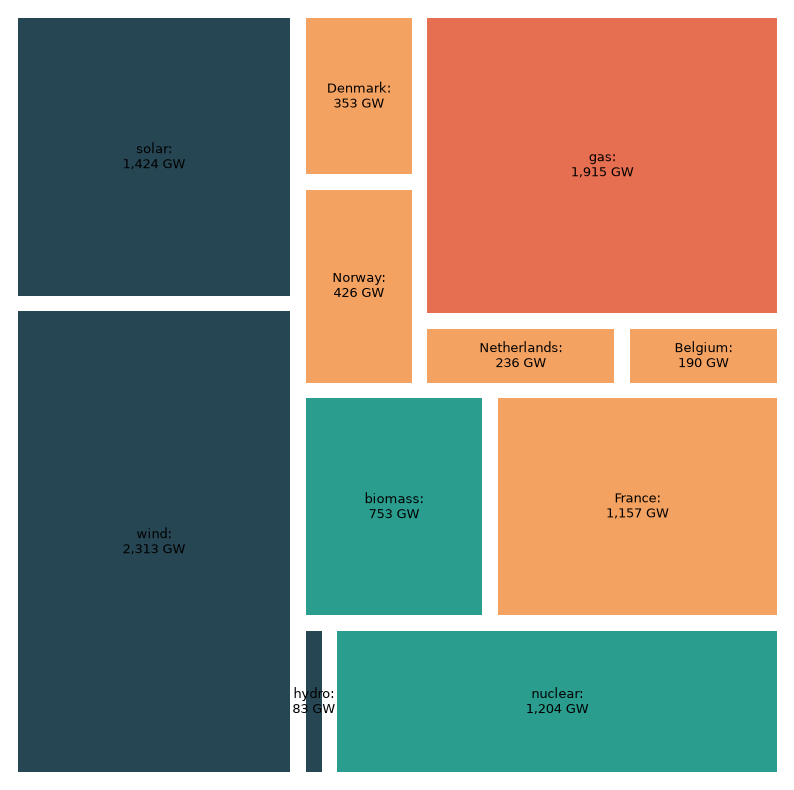

In [ ]:
# treemap data preparation
heatmap_data = grid_long.groupby(['category', 'source'], as_index=False)['mw'].sum()
heatmap_data = heatmap_data[heatmap_data['mw'] > 0].dropna(subset='mw')

# interconnector connecting countries
interconnector_map = {
    'INTELEC': 'France', 
        'INTFR': 'France', 
        'INTIFA2': 'France',
        'INTNED': 'Netherlands', 
        'INTIRL': 'Ireland', 
        'INTEW': 'Ireland', 
        'INTGRNL': 'Ireland', 
        'INTNEM': 'Belgium', 
        'INTNSL': 'Norway', 
        'INTVKL': 'Denmark'
}

# prepare final plot DataFrame
heatmap_data['type'] = heatmap_data['source'].map(interconnector_map).fillna(heatmap_data['source'])
heatmap_data = heatmap_data.groupby(['category', 'type'], as_index=False)['mw'].sum()
heatmap_data = heatmap_data.sort_values(by=['category','mw'], ascending=[False, False])
heatmap_data = heatmap_data[heatmap_data['mw'] >= 10000]


labels = [
    f"{type.title()}:\n{(mw / 1000):,.0f} GW"
    for type, mw in zip(heatmap_data['type'], heatmap_data['mw'])
]

# treemap visualization
colour_map = {
    'Fossil' : '#e76f51', 
    'Interconnector': '#f4a261', 
    'Other': '#2a9d8f', 
    'Renewable': '#264653'
}

colors = heatmap_data['category'].map(colour_map)

fig, ax = plt.subplots(figsize=(10,10))
ax.set_axis_off()

squarify.plot(sizes=heatmap_data['mw'], 
              label=labels, 
              color = colors, 
              pad=True)

In [ ]:


print(labels)

['wind:\n2313.47', 'solar:\n1424.486', 'hydro:\n83.327', 'nuclear:\n1204.157', 'biomass:\n753.384', 'France:\n1157.292', 'Norway:\n426.466', 'Denmark:\n352.906', 'Netherlands:\n236.002', 'Belgium:\n190.094', 'gas:\n1914.59']


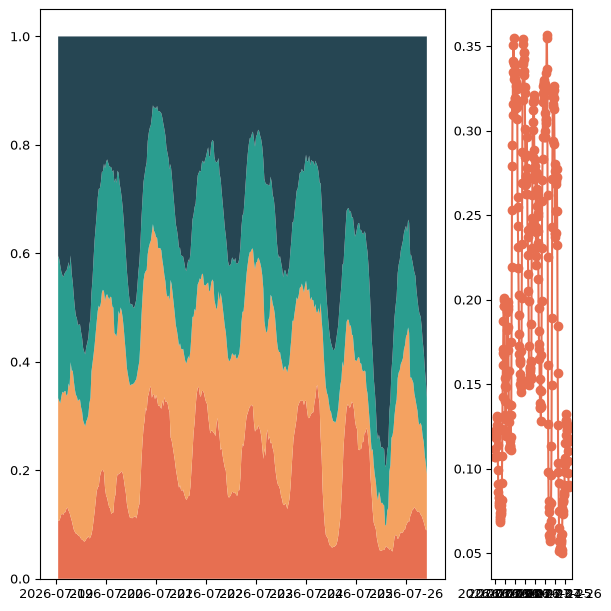

In [48]:
# plot 1 - stacked area 30 min generation
cat_data = grid_long.groupby(['timestamp', 'category'])['mw'].sum().reset_index()
cat_wide = cat_data.pivot(index='timestamp', columns='category', values='mw').fillna(0)
cat_perc = cat_wide.div(cat_wide.sum(axis=1), axis=0)

# plot 2 - stacked bar weekly summary




fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6,6), gridspec_kw={'width_ratios': [5, 1]},
                               layout='constrained')

plt.rcParams.update({'font.size': 9})
title_font = {'fontname':'Karla',
              'fontsize': 20}

colour = ['#e76f51', '#f4a261', '#2a9d8f', '#264653']

ax1.stackplot(cat_perc.index,
              cat_perc.T,
              labels=cat_perc.columns,
              colors=colour)

ax2.plot(cat_perc.index, cat_perc.iloc[:, 0], color=colour[0], marker='o')

plt.show()


In [49]:
print(cat_data.head(10))

            timestamp        category      mw
0 2026-07-19 01:00:00          Fossil  2415.0
1 2026-07-19 01:00:00  Interconnector  5122.0
2 2026-07-19 01:00:00           Other  5929.0
3 2026-07-19 01:00:00       Renewable  9166.0
4 2026-07-19 01:30:00          Fossil  2418.0
5 2026-07-19 01:30:00  Interconnector  4996.0
6 2026-07-19 01:30:00           Other  5914.0
7 2026-07-19 01:30:00       Renewable  9267.0
8 2026-07-19 02:00:00          Fossil  2473.0
9 2026-07-19 02:00:00  Interconnector  4692.0
